In [8]:
import os
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image

# Set your API Key (Replace with your own or use an .env file)
# os.environ["OPENAI_API_KEY"] = "your-key-here"
os.environ["GOOGLE_API_KEY"] = "your-key-here"

print("✅ Setup Complete")

✅ Setup Complete


In [2]:
# --- CELL 2: THE SHARED CLIPBOARD (STATE) ---
class SentinelState(TypedDict):
    ticker: str
    price_data: str      # Worker 1's output
    news_sentiment: str   # Worker 2's output
    final_combined_report: str

In [3]:
# --- CELL 3: THE PARALLEL WORKERS (NODES) ---
def price_analyst_node(state: SentinelState):
    print("📈 Price Analyst: Checking charts...")
    # Simulated work
    return {"price_data": "Price is $180, currently trading above 50-day MA."}

def news_analyst_node(state: SentinelState):
    print("📰 News Analyst: Scanning headlines...")
    # Simulated work
    return {"news_sentiment": "Positive sentiment regarding new product launch."}

def aggregator_node(state: SentinelState):
    print("🤝 Aggregator: Merging reports...")
    combined = f"REPORT FOR {state['ticker']}:\n- Market: {state['price_data']}\n- Sentiment: {state['news_sentiment']}"
    return {"final_combined_report": combined}

In [4]:
# --- CELL 4: THE FLOOR PLAN (GRAPH) ---
builder = StateGraph(SentinelState)

# 1. Add Nodes
builder.add_node("price_specialist", price_analyst_node)
builder.add_node("news_specialist", news_analyst_node)
builder.add_node("aggregator", aggregator_node)

# 2. Define Parallel Flow
# Start sends the state to BOTH specialists at the same time
builder.add_edge(START, "price_specialist")
builder.add_edge(START, "news_specialist")

# Both specialists send their work to the aggregator
builder.add_edge("price_specialist", "aggregator")
builder.add_edge("news_specialist", "aggregator")

builder.add_edge("aggregator", END)

sentinel_parallel = builder.compile()

In [5]:
# --- CELL 5: RUNNING THE LINE ---
result = sentinel_parallel.invoke({"ticker": "AAPL"})
print("\n" + result['final_combined_report'])

📰 News Analyst: Scanning headlines...
📈 Price Analyst: Checking charts...
🤝 Aggregator: Merging reports...

REPORT FOR AAPL:
- Market: Price is $180, currently trading above 50-day MA.
- Sentiment: Positive sentiment regarding new product launch.


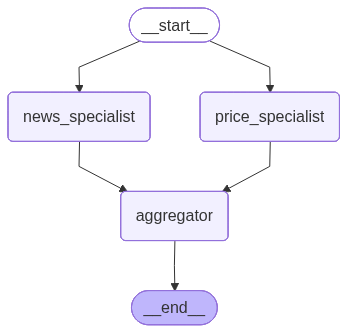

In [14]:
png_bytes = sentinel_parallel.get_graph().draw_mermaid_png()

# Save to file
with open("sentinel_parallel.png", "wb") as f:
    f.write(png_bytes)

# Display in notebook
display(Image(data=png_bytes))